<a href="https://colab.research.google.com/github/albert-magarire/Data-Science-and-ML/blob/main/HoverNet_CryoNuseg.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
import os

try:
    drive.flush_and_unmount()
except ValueError:
    pass # Drive was not mounted, nothing to unmount.

# Ensure the mount point is clean before mounting
if os.path.exists('/content/drive') and os.path.isdir('/content/drive') and len(os.listdir('/content/drive')) > 0:
    # If it's a non-empty directory, try to remove it
    # This handles cases where a previous mount failed or left artifacts
    try:
        os.rmdir('/content/drive') # rmdir only removes empty directories
    except OSError:
        # If rmdir fails (directory not empty), then remove recursively
        import shutil
        shutil.rmtree('/content/drive')

drive.mount('/content/drive', force_remount=True)

Drive not mounted, so nothing to flush and unmount.
Mounted at /content/drive


In [2]:
import subprocess, sys, os

for pkg in ['imgaug==0.4.0', 'tensorboardX', 'docopt', 'termcolor',
            'scikit-image', 'scikit-learn', 'scipy', 'tqdm',
            'opencv-python-headless', 'gdown']:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', pkg, '--quiet'])

REPO_PATH = '/content/hover_net'
if not os.path.isdir(REPO_PATH):
    os.system(f'git clone https://github.com/vqdang/hover_net.git {REPO_PATH}')

import torch
print(f'CUDA available: {torch.cuda.is_available()}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')

CUDA available: True
GPU: NVIDIA RTX PRO 6000 Blackwell Server Edition


In [3]:
import os

REPO_PATH = '/content/hover_net'

# --- DATA PATHS (update to match your Google Drive) ---
GDRIVE_TRAIN_PATH = '/content/drive/MyDrive/Data_jiacheng/CryoNuSeg_Combined/train'
GDRIVE_VALID_PATH = '/content/drive/MyDrive/Data_jiacheng/CryoNuSeg_Combined/val'
GDRIVE_TEST_PATH  = '/content/drive/MyDrive/Data_jiacheng/CryoNuSeg_Combined/test'
IMG_SUBDIR  = 'images'
MASK_SUBDIR = 'masks'

PATCH_ROOT      = '/content/hovernet_patches'
TRAIN_PATCH_DIR = os.path.join(PATCH_ROOT, 'train')
VALID_PATCH_DIR = os.path.join(PATCH_ROOT, 'valid')
TEST_PATCH_DIR  = os.path.join(PATCH_ROOT, 'test')

# --- MODEL ---
MODEL_MODE           = 'fast'
TYPE_CLASSIFICATION  = False
NR_TYPES             = None

# ImageNet-pretrained Preact-ResNet50 backbone (downloaded in next cell)
PRETRAINED_PATH = '/content/pretrained/pretrained_net.tar'

# --- TRAINING ---
NR_EPOCHS_PHASE1  = 50
NR_EPOCHS_PHASE2  = 50
BATCH_SIZE_PHASE1 = 8
BATCH_SIZE_PHASE2 = 8
LEARNING_RATE     = 1.0e-4
NR_DATA_WORKERS   = 4
LOG_DIR           = '/content/hovernet_logs'
GPU_IDS           = '0'
SEED              = 10

print('Configuration loaded.')
print(f'  Pretrained:   {PRETRAINED_PATH}')
print(f'  Total epochs: {NR_EPOCHS_PHASE1 + NR_EPOCHS_PHASE2}')

Configuration loaded.
  Pretrained:   /content/pretrained/pretrained_net.tar
  Total epochs: 100


In [4]:
import os, gdown

pretrained_dir = '/content/pretrained'
os.makedirs(pretrained_dir, exist_ok=True)

if not os.path.exists(PRETRAINED_PATH):
    print('Downloading ImageNet-pretrained Preact-ResNet50 backbone...')
    gdown.download(
        'https://drive.google.com/uc?id=1KntZge40tAHgyXmHYVqZZ5d2p_4Qr2l5',
        PRETRAINED_PATH, quiet=False
    )
    print(f'Saved to {PRETRAINED_PATH}')
else:
    print(f'Pretrained weights already exist at {PRETRAINED_PATH}')

assert os.path.exists(PRETRAINED_PATH), (
    f'Failed to download pretrained weights. '
    f'Manually download from https://drive.google.com/uc?id=1KntZge40tAHgyXmHYVqZZ5d2p_4Qr2l5 '
    f'and place at {PRETRAINED_PATH}'
)

Downloading...
From: https://drive.google.com/uc?id=1KntZge40tAHgyXmHYVqZZ5d2p_4Qr2l5
To: /content/pretrained/pretrained_net.tar
100%|██████████| 94.2M/94.2M [00:00<00:00, 141MB/s]

Saved to /content/pretrained/pretrained_net.tar


In [6]:
import os, sys, importlib, numpy as np

sys.path.insert(0, REPO_PATH)
os.chdir(REPO_PATH)

# --- Patch np.lib.pad → np.pad ---
pe_path = os.path.join(REPO_PATH, 'misc/patch_extractor.py')
if os.path.exists(pe_path):
    with open(pe_path, 'r') as f:
        code = f.read()
    if 'np.lib.pad' in code:
        with open(pe_path, 'w') as f:
            f.write(code.replace('np.lib.pad', 'np.pad'))
        print('Patched: np.lib.pad -> np.pad')

# --- Patch np.sctypes for imgaug ---
if not hasattr(np, 'sctypes'):
    np.sctypes = {
        'float': [np.float16, np.float32, np.float64],
        'int': [np.int8, np.int16, np.int32, np.int64],
        'uint': [np.uint8, np.uint16, np.uint32, np.uint64],
        'complex': [np.complex64, np.complex128]
    }
    if hasattr(np, 'float128'):
        np.sctypes['float'].append(np.float128)
    print('Patched: np.sctypes for imgaug')

# --- Patch viz_step_output shape alignment ---
rd_path = os.path.join(REPO_PATH, 'models/hovernet/run_desc.py')
if os.path.exists(rd_path):
    with open(rd_path, 'r') as f:
        code = f.read()
    old_line = "aligned_shape = np.min(np.array(aligned_shape), axis=0)[1:3]"
    if old_line in code:
        new_logic = (
            "    shapes = [imgs.shape, true_np.shape, pred_np.shape]\n"
            "    min_h = min(s[1] for s in shapes)\n"
            "    min_w = min(s[2] for s in shapes)\n"
            "    aligned_shape = [min_h, min_w]"
        )
        code = code.replace(
            "aligned_shape = [list(imgs.shape), list(true_np.shape), list(pred_np.shape)]",
            "# aligned_shape = ..."
        )
        code = code.replace(old_line, new_logic)
        with open(rd_path, 'w') as f:
            f.write(code)
        print('Patched: viz_step_output shape alignment')

# --- Inject focal_loss into run_desc.py ---
with open(rd_path, 'r') as f:
    code = f.read()

focal_loss_code = '''
def focal_loss(true, pred):
    gamma = 2.0
    eps = 1e-7
    pred = torch.clamp(pred, eps, 1. - eps)
    pt = (true * pred).sum(dim=-1)
    loss = -((1 - pt) ** gamma) * torch.log(pt)
    return loss.mean()

'''

if 'def focal_loss' not in code:
    code = code.replace('def train_step(', focal_loss_code + 'def train_step(')
    print('Injected: focal_loss function')

if '"focal": focal_loss' not in code:
    code = code.replace('"msge": msge_loss,', '"msge": msge_loss,\n        "focal": focal_loss,')
    print('Registered: focal in loss_func_dict')

with open(rd_path, 'w') as f:
    f.write(code)

# --- Patch JSON serialization (float32) ---
log_path = os.path.join(REPO_PATH, 'run_utils/callbacks/logging.py')
if os.path.exists(log_path):
    with open(log_path, 'r') as f:
        code = f.read()
    if 'class NumpyEncoder' not in code:
        encoder = '''
import json as _json
import numpy as _np
class NumpyEncoder(_json.JSONEncoder):
    def default(self, obj):
        if isinstance(obj, _np.integer): return int(obj)
        elif isinstance(obj, _np.floating): return float(obj)
        elif isinstance(obj, _np.ndarray): return obj.tolist()
        return super().default(obj)

'''
        code = code.replace('class LoggingEpochOutput', encoder + 'class LoggingEpochOutput')
        code = code.replace('json.dump(json_data, json_file)', 'json.dump(json_data, json_file, cls=NumpyEncoder)')
        with open(log_path, 'w') as f:
            f.write(code)
        print('Patched: JSON NumpyEncoder')

# --- Patch NaN Center of Mass in targets.py ---
tgt_path = os.path.join(REPO_PATH, 'models/hovernet/targets.py')
if os.path.exists(tgt_path):
    with open(tgt_path, 'r') as f:
        code = f.read()
    old_block = "inst_com[0] = int(inst_com[0] + 0.5)"
    if old_block in code and "if np.any(np.isnan(inst_com))" not in code:
        code = code.replace(old_block, "if np.any(np.isnan(inst_com)): continue\n        inst_com[0] = int(inst_com[0] + 0.5)")
        with open(tgt_path, 'w') as f:
            f.write(code)
        print('Patched: NaN center-of-mass guard')

# Force-reload all patched modules
for mod_name in list(sys.modules.keys()):
    if any(k in mod_name for k in ['hover', 'run_utils', 'misc.patch', 'dataloader']):
        del sys.modules[mod_name]

print('All patches applied.')

All patches applied.


In [7]:
import glob, pathlib, shutil, warnings, cv2, numpy as np
from scipy import ndimage
import tqdm

sys.path.insert(0, REPO_PATH)
from misc.patch_extractor import PatchExtractor

WIN_SIZE  = [540, 540]
STEP_SIZE = [164, 164]
IMG_EXTENSIONS = ['.png', '.jpg', '.jpeg', '.tiff', '.tif', '.bmp']

def load_instance_mask(mask_path):
    mask = cv2.imread(mask_path, cv2.IMREAD_UNCHANGED)
    if mask is None:
        return None
    if mask.ndim == 3:
        if mask.shape[2] == 4:
            mask = mask[:, :, 0]
        elif mask.shape[2] == 3:
            mask = cv2.cvtColor(mask, cv2.COLOR_BGR2GRAY)
        else:
            mask = mask[:, :, 0]
    mask = mask.astype(np.int32)
    unique_vals = np.unique(mask)
    non_bg = unique_vals[unique_vals != 0]
    if len(non_bg) <= 1:
        binary = (mask > 0).astype(np.uint8)
        labeled, _ = ndimage.label(binary)
        mask = labeled.astype(np.int32)
    return mask

def find_mask_path(img_stem, mask_dir):
    for base in [img_stem, img_stem + '_mask']:
        for ext in IMG_EXTENSIONS:
            for e in [ext, ext.upper()]:
                path = os.path.join(mask_dir, base + e)
                if os.path.exists(path):
                    return path
    return None

def extract_and_save(file_list, out_dir, split_name, img_dir, mask_dir):
    xtractor = PatchExtractor(WIN_SIZE, STEP_SIZE)
    total_patches, skipped = 0, 0
    for img_path in tqdm.tqdm(file_list, desc=f'Extracting {split_name}'):
        stem = pathlib.Path(img_path).stem
        img_bgr = cv2.imread(img_path)
        if img_bgr is None:
            skipped += 1; continue
        img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
        mask_path = find_mask_path(stem, mask_dir)
        if mask_path is None:
            skipped += 1; continue
        inst_map = load_instance_mask(mask_path)
        if inst_map is None:
            skipped += 1; continue
        if img_rgb.shape[:2] != inst_map.shape[:2]:
            inst_map = cv2.resize(inst_map, (img_rgb.shape[1], img_rgb.shape[0]),
                                  interpolation=cv2.INTER_NEAREST).astype(np.int32)
        stacked = np.concatenate([img_rgb, inst_map[:, :, np.newaxis]], axis=-1)
        patches = xtractor.extract(stacked, 'mirror')
        for idx, patch in enumerate(patches):
            np.save(os.path.join(out_dir, f'{stem}_{idx:04d}.npy'), patch)
        total_patches += len(patches)
    print(f'  {split_name}: {total_patches} patches from {len(file_list)} images ({skipped} skipped)')
    return total_patches

def get_image_files(base_dir):
    img_dir  = os.path.join(base_dir, IMG_SUBDIR)
    mask_dir = os.path.join(base_dir, MASK_SUBDIR)
    assert os.path.isdir(img_dir),  f'Not found: {img_dir}'
    assert os.path.isdir(mask_dir), f'Not found: {mask_dir}'
    files = []
    for ext in IMG_EXTENSIONS:
        files += glob.glob(os.path.join(img_dir, f'*{ext}'))
        files += glob.glob(os.path.join(img_dir, f'*{ext.upper()}'))
    return sorted(set(files)), img_dir, mask_dir

for split_name, src_path, dst_dir in [
    ('train', GDRIVE_TRAIN_PATH, TRAIN_PATCH_DIR),
    ('valid', GDRIVE_VALID_PATH, VALID_PATCH_DIR),
    ('test',  GDRIVE_TEST_PATH,  TEST_PATCH_DIR),
]:
    if os.path.isdir(dst_dir):
        shutil.rmtree(dst_dir)
    os.makedirs(dst_dir)
    files, img_dir, mask_dir = get_image_files(src_path)
    print(f'{split_name}: {len(files)} images found')
    extract_and_save(files, dst_dir, split_name, img_dir, mask_dir)

print('Data preparation complete.')

train: 15 images found


Extracting train: 100%|██████████| 15/15 [00:47<00:00,  3.16s/it]


  train: 240 patches from 15 images (0 skipped)
valid: 5 images found


Extracting valid: 100%|██████████| 5/5 [00:15<00:00,  3.01s/it]


  valid: 80 patches from 5 images (0 skipped)
test: 10 images found


Extracting test: 100%|██████████| 10/10 [00:32<00:00,  3.22s/it]

  test: 160 patches from 10 images (0 skipped)
Data preparation complete.


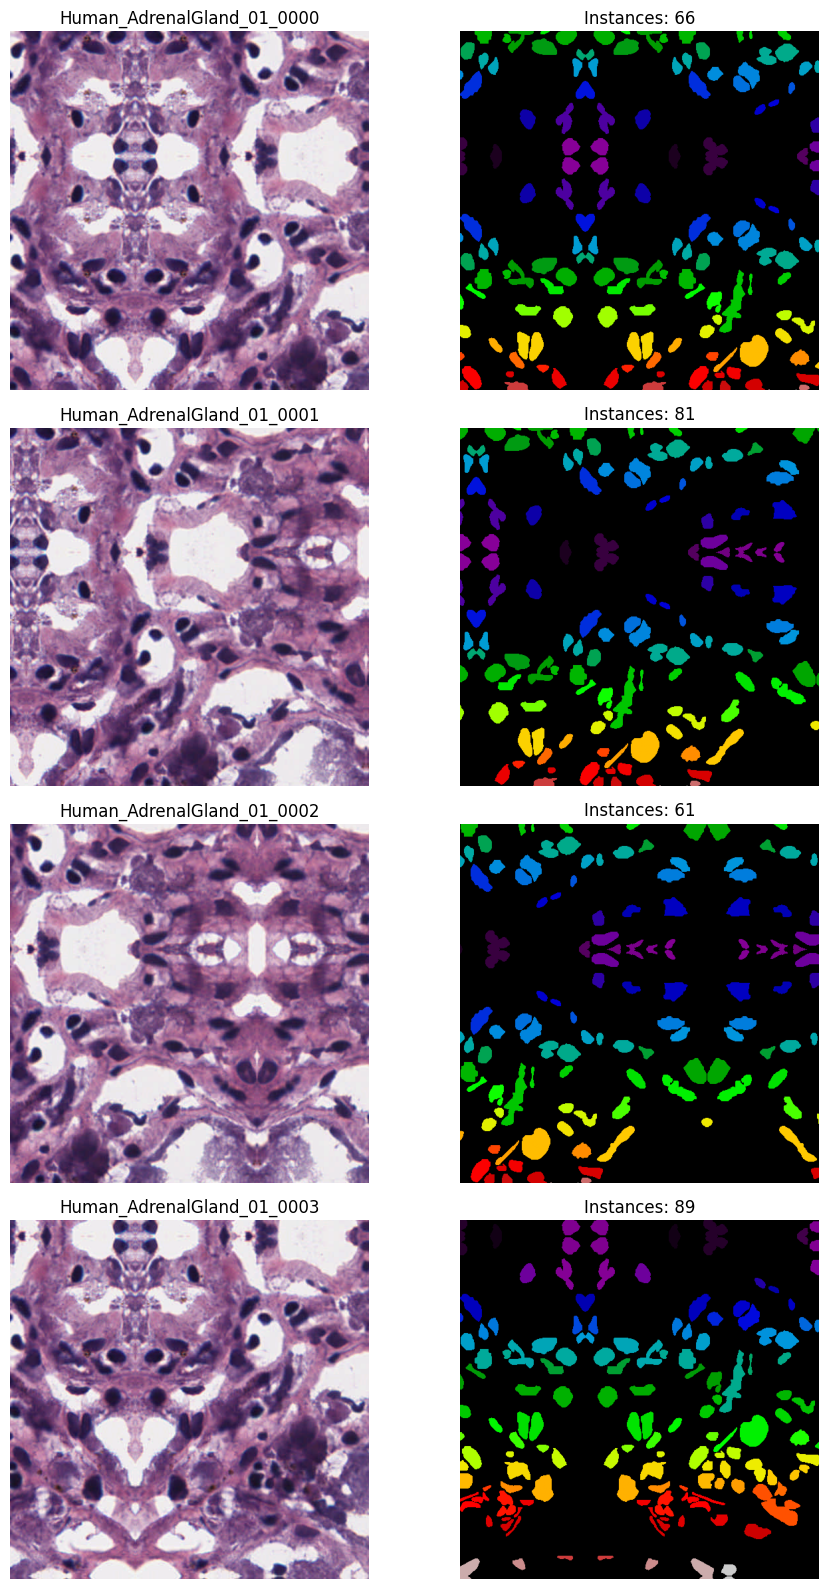

  Train: 240 patches
  Valid: 80 patches
  Test: 160 patches


In [8]:
import matplotlib.pyplot as plt, numpy as np, glob, pathlib

sample_files = sorted(glob.glob(os.path.join(TRAIN_PATCH_DIR, '*.npy')))[:4]
assert len(sample_files) > 0, 'No training patches found!'

fig, axes = plt.subplots(len(sample_files), 2, figsize=(10, 4 * len(sample_files)))
if len(sample_files) == 1:
    axes = [axes]
for i, fpath in enumerate(sample_files):
    data = np.load(fpath)
    axes[i][0].imshow(data[..., :3].astype('uint8'))
    axes[i][0].set_title(pathlib.Path(fpath).stem); axes[i][0].axis('off')
    inst = data[..., 3].astype('int32')
    axes[i][1].imshow(inst, cmap='nipy_spectral')
    axes[i][1].set_title(f'Instances: {len(np.unique(inst)) - 1}'); axes[i][1].axis('off')
plt.tight_layout(); plt.show()

for label, d in [('Train', TRAIN_PATCH_DIR), ('Valid', VALID_PATCH_DIR), ('Test', TEST_PATCH_DIR)]:
    n = len(glob.glob(os.path.join(d, '*.npy')))
    print(f'  {label}: {n} patches')

In [9]:
import cv2; cv2.setNumThreads(0)
import json, shutil, random, glob, time
import numpy as np, torch, torch.optim as optim
from torch.nn import DataParallel
from torch.utils.data import DataLoader
from tensorboardX import SummaryWriter

import sys, os, importlib
sys.path.insert(0, REPO_PATH)
os.chdir(REPO_PATH)

from dataloader.train_loader import FileLoader
from models.hovernet.net_desc import create_model
from models.hovernet.targets import gen_targets, prep_sample
from models.hovernet.run_desc import (
    proc_valid_step_output, train_step, valid_step, viz_step_output
)
from run_utils.engine import RunEngine, Events
from run_utils.callbacks.base import (
    AccumulateRawOutput, BaseCallbacks, PeriodicSaver,
    ProcessAccumulatedRawOutput, ScalarMovingAverage,
    ScheduleLr, TrackLr, VisualizeOutput, TriggerEngine,
)
from run_utils.callbacks.logging import LoggingEpochOutput
from run_utils.utils import check_manual_seed, convert_pytorch_checkpoint
from misc.utils import rm_n_mkdir

def worker_init_fn(worker_id):
    worker_info = torch.utils.data.get_worker_info()
    worker_seed = torch.randint(0, 2**32, (1,))[0].cpu().item() + worker_id
    worker_info.dataset.setup_augmentor(worker_id, worker_seed)

class BestCheckpointSaver(BaseCallbacks):
    def __init__(self, metric_name='valid-np_dice', mode='max', filename='net_best_checkpoint'):
        super().__init__()
        self.metric_name = metric_name
        self.mode = mode
        self.filename = filename
        self.best_value = -float('inf') if mode == 'max' else float('inf')
        self.best_epoch = -1

    def run(self, state, event):
        if not state.logging:
            return
        current_epoch_str = str(
            state.global_state.curr_epoch if state.global_state else state.curr_epoch
        )
        try:
            with open(state.log_info['json_file']) as fh:
                json_data = json.load(fh)
        except Exception:
            return
        if current_epoch_str not in json_data:
            return
        epoch_stats = json_data[current_epoch_str]
        if self.metric_name not in epoch_stats:
            return
        current_value = float(epoch_stats[self.metric_name])
        is_best = (
            (self.mode == 'max' and current_value > self.best_value) or
            (self.mode == 'min' and current_value < self.best_value)
        )
        if is_best:
            self.best_value = current_value
            self.best_epoch = int(current_epoch_str)
            print(f'\n  [BEST] Epoch {self.best_epoch}: '
                  f'{self.metric_name} = {current_value:.4f}')

            # ---- THE FIX: Save in the SAME format as PeriodicSaver ----
            # PeriodicSaver saves: {k: v.state_dict() for k, v in net_info.items() if k != 'extra_info'}
            # which gives: {'desc': model.state_dict(), 'optimizer': opt.state_dict(), 'lr_scheduler': sched.state_dict()}
            # We replicate this exactly, plus record the epoch number.
            for net_name, net_info in state.run_info.items():
                checkpoint = {
                    k: v.state_dict()
                    for k, v in net_info.items()
                    if k != 'extra_info'
                }
                checkpoint['epoch'] = self.best_epoch
                save_path = os.path.join(state.log_dir, f'{self.filename}.tar')
                torch.save(checkpoint, save_path)
                print(f'  Saved best checkpoint to: {save_path}')

def run_phase(phase_info, phase_dir, prev_phase_dir=None, seed=SEED):
    nr_gpus = max(1, torch.cuda.device_count())
    check_manual_seed(seed)
    rm_n_mkdir(phase_dir)
    tfwriter = SummaryWriter(log_dir=phase_dir)
    json_log_file = os.path.join(phase_dir, 'stats.json')
    with open(json_log_file, 'w') as fh:
        json.dump({}, fh)
    log_info = {'json_file': json_log_file, 'tfwriter': tfwriter}

    if MODEL_MODE == 'original':
        act_shape, out_shape = [270, 270], [80, 80]
    else:
        act_shape, out_shape = [256, 256], [164, 164]
    shape_info = {
        'train': {'input_shape': act_shape, 'mask_shape': out_shape},
        'valid': {'input_shape': act_shape, 'mask_shape': out_shape},
    }

    def build_loader(patch_dir, mode, batch_size, nr_procs):
        file_list = sorted(glob.glob(os.path.join(patch_dir, '*.npy')))
        assert len(file_list) > 0, f'No .npy files in {patch_dir}'
        print(f'  {mode:5s}: {len(file_list)} patches')
        dataset = FileLoader(
            file_list, mode=mode, with_type=TYPE_CLASSIFICATION,
            setup_augmentor=(nr_procs == 0),
            target_gen=phase_info['target_info']['gen'],
            **shape_info[mode]
        )
        return DataLoader(
            dataset, num_workers=nr_procs, batch_size=batch_size * nr_gpus,
            shuffle=(mode == 'train'), drop_last=True,
            worker_init_fn=worker_init_fn,
        )

    print('Loading datasets...')
    loaders = {
        'train': build_loader(TRAIN_PATCH_DIR, 'train', phase_info['batch_size']['train'], NR_DATA_WORKERS),
        'valid': build_loader(VALID_PATCH_DIR, 'valid', phase_info['batch_size']['valid'], max(1, NR_DATA_WORKERS // 2)),
    }

    net_run_info = {}
    for net_name, net_info in phase_info['run_info'].items():
        net = net_info['desc']()
        pretrained = net_info['pretrained']
        if pretrained is not None:
            if pretrained == -1:
                assert prev_phase_dir is not None
                prev_stats_path = os.path.join(prev_phase_dir, 'stats.json')
                with open(prev_stats_path) as fh:
                    prev_stats = json.load(fh)
                last_epoch = max(int(e) for e in prev_stats.keys())
                pretrained = os.path.join(prev_phase_dir, f'{net_name}_epoch={last_epoch}.tar')
                print(f'  Auto-loading Phase 1 checkpoint: {pretrained}')
                state_dict = torch.load(pretrained)['desc']
            else:
                print(f'  Loading pretrained weights: {pretrained}')
                ext = pretrained.rsplit('.', 1)[-1]
                if ext == 'npz':
                    state_dict = {k: torch.from_numpy(v) for k, v in dict(np.load(pretrained)).items()}
                else:
                    state_dict = torch.load(pretrained)['desc']
            state_dict = convert_pytorch_checkpoint(state_dict)
            missing, unexpected = net.load_state_dict(state_dict, strict=False)
            if missing:
                print(f'  Missing keys ({len(missing)}): {missing[:3]}')
            if unexpected:
                print(f'  Unexpected keys ({len(unexpected)}): {unexpected[:3]}')

        net = DataParallel(net).to('cuda')
        opt_cls, opt_kwargs = net_info['optimizer']
        optimizer = opt_cls(net.parameters(), **opt_kwargs)
        scheduler = net_info['lr_scheduler'](optimizer)
        net_run_info[net_name] = {
            'desc': net, 'optimizer': optimizer,
            'lr_scheduler': scheduler, 'extra_info': net_info['extra_info'],
        }

    nr_type = NR_TYPES
    run_engine_opt = {
        'train': {
            'run_step': train_step,
            'callbacks': {
                Events.STEP_COMPLETED: [ScalarMovingAverage()],
                Events.EPOCH_COMPLETED: [
                    TrackLr(), PeriodicSaver(per_n_epoch=5),
                    VisualizeOutput(viz_step_output), LoggingEpochOutput(),
                    TriggerEngine('valid'), ScheduleLr(),
                ],
            },
        },
        'valid': {
            'run_step': valid_step,
            'callbacks': {
                Events.STEP_COMPLETED: [AccumulateRawOutput()],
                Events.EPOCH_COMPLETED: [
                    ProcessAccumulatedRawOutput(
                        lambda a: proc_valid_step_output(a, nr_types=nr_type)
                    ),
                    LoggingEpochOutput(),
                    BestCheckpointSaver('valid-np_dice', 'max'),
                ],
            },
        },
    }

    runner_dict = {
        name: RunEngine(
            dataloader=loaders[name], engine_name=name,
            run_step=opt['run_step'], run_info=net_run_info, log_info=log_info,
        )
        for name, opt in run_engine_opt.items()
    }
    for name, runner in runner_dict.items():
        for event, cbs in run_engine_opt[name]['callbacks'].items():
            for cb in cbs:
                if cb.engine_trigger:
                    cb.triggered_engine = runner_dict[cb.triggered_engine_name]
                runner.add_event_handler(event, cb)
        runner.state.logging = True
        runner.state.log_dir = phase_dir
    runner_dict['train'].run(phase_info['nr_epochs'])

def build_phase_list():
    nr_type = NR_TYPES
    loss_cfg = {
        'np': {'focal': 1, 'dice': 1},
        'hv': {'mse': 2, 'msge': 2},
    }
    if nr_type is not None:
        loss_cfg['tp'] = {'focal': 1, 'dice': 1}
    print(f'Loss config: {loss_cfg}')
    return [
        {
            'run_info': {
                'net': {
                    'desc': lambda: create_model(input_ch=3, nr_types=nr_type, freeze=True, mode=MODEL_MODE),
                    'optimizer': [optim.Adam, {'lr': LEARNING_RATE, 'betas': (0.9, 0.999)}],
                    'lr_scheduler': lambda x: optim.lr_scheduler.StepLR(x, 25),
                    'extra_info': {'loss': loss_cfg},
                    'pretrained': PRETRAINED_PATH,
                },
            },
            'target_info': {'gen': (gen_targets, {}), 'viz': (prep_sample, {})},
            'batch_size': {'train': BATCH_SIZE_PHASE1, 'valid': BATCH_SIZE_PHASE1},
            'nr_epochs': NR_EPOCHS_PHASE1,
        },
        {
            'run_info': {
                'net': {
                    'desc': lambda: create_model(input_ch=3, nr_types=nr_type, freeze=False, mode=MODEL_MODE),
                    'optimizer': [optim.Adam, {'lr': LEARNING_RATE * 0.5, 'betas': (0.9, 0.999)}],
                    'lr_scheduler': lambda x: optim.lr_scheduler.CosineAnnealingLR(x, T_max=NR_EPOCHS_PHASE2, eta_min=1e-6),
                    'extra_info': {'loss': loss_cfg},
                    'pretrained': -1,
                },
            },
            'target_info': {'gen': (gen_targets, {}), 'viz': (prep_sample, {})},
            'batch_size': {'train': BATCH_SIZE_PHASE2, 'valid': BATCH_SIZE_PHASE2},
            'nr_epochs': NR_EPOCHS_PHASE2,
        },
    ]

print('Training infrastructure ready.')

Training infrastructure ready.


In [10]:
import numpy as np, glob

sample_patches = sorted(glob.glob(os.path.join(TRAIN_PATCH_DIR, '*.npy')))[:10]
for fpath in sample_patches:
    data = np.load(fpath)
    inst = data[..., 3].astype(np.int32)
    unique_ids = np.unique(inst)
    n_nuclei = len(unique_ids) - 1  # subtract background
    max_id = unique_ids.max()
    print(f'{os.path.basename(fpath)}: {n_nuclei} nuclei, '
          f'IDs: {unique_ids[:8]}... max_id={max_id}')
    if max_id <= 1 and n_nuclei > 0:
        print('  ⚠️ WARNING: Mask appears BINARY (only 0 and 1)')
        print('     HoVer-Net needs INSTANCE labels (0, 1, 2, 3, ... N)')
        print('     Each nucleus must have a unique integer ID!')

Human_AdrenalGland_01_0000.npy: 66 nuclei, IDs: [ 0  1  2  3  8  9 10 11]... max_id=81
Human_AdrenalGland_01_0001.npy: 81 nuclei, IDs: [0 1 2 3 4 5 6 7]... max_id=81
Human_AdrenalGland_01_0002.npy: 61 nuclei, IDs: [0 1 2 3 4 5 6 7]... max_id=81
Human_AdrenalGland_01_0003.npy: 89 nuclei, IDs: [ 0  1  2  3  8  9 10 11]... max_id=107
Human_AdrenalGland_01_0004.npy: 107 nuclei, IDs: [0 1 2 3 4 5 6 7]... max_id=107
Human_AdrenalGland_01_0005.npy: 77 nuclei, IDs: [0 1 2 3 4 5 6 7]... max_id=107
Human_AdrenalGland_01_0006.npy: 74 nuclei, IDs: [ 0 22 25 26 27 28 29 31]... max_id=107
Human_AdrenalGland_01_0007.npy: 84 nuclei, IDs: [ 0 22 25 26 27 28 29 30]... max_id=107
Human_AdrenalGland_01_0008.npy: 58 nuclei, IDs: [ 0 22 26 27 28 29 30 31]... max_id=107
Human_AdrenalGland_01_0009.npy: 68 nuclei, IDs: [ 0 31 32 33 34 36 37 39]... max_id=107


In [11]:
import time, torch
os.environ['CUDA_VISIBLE_DEVICES'] = GPU_IDS
assert torch.cuda.is_available(), 'No GPU! Go to Runtime → Change runtime type → GPU'

phase_list = build_phase_list()
prev_phase_dir = None

for phase_idx, phase_info in enumerate(phase_list):
    phase_dir = os.path.join(LOG_DIR, f'{phase_idx:02d}')
    label = 'FROZEN backbone' if phase_idx == 0 else 'FULL model'
    print(f'\n{"="*60}')
    print(f'  PHASE {phase_idx+1}/{len(phase_list)}: {label} | Epochs: {phase_info["nr_epochs"]}')
    print(f'{"="*60}')
    t0 = time.time()
    run_phase(phase_info, phase_dir, prev_phase_dir=prev_phase_dir)
    print(f'  Phase {phase_idx+1} finished in {(time.time()-t0)/60:.1f} min.')
    prev_phase_dir = phase_dir

print(f'\n{"="*60}')
print('  TRAINING COMPLETE')
print(f'{"="*60}')

Loss config: {'np': {'focal': 1, 'dice': 1}, 'hv': {'mse': 2, 'msge': 2}}

  PHASE 1/2: FROZEN backbone | Epochs: 50
Using manual seed: 10
Loading datasets...
  train: 240 patches
  valid: 80 patches
  Loading pretrained weights: /content/pretrained/pretrained_net.tar
  Missing keys (279): ['conv_bot.weight', 'decoder.np.u3.conva.weight', 'decoder.np.u3.dense.units.0.preact_bna/bn.weight']
----------------EPOCH 1


Processing: |          | 0/30[00:00<?,?it/s]Batch = nan|EMA = nan/usr/local/lib/python3.12/dist-packages/torch/functional.py:505: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at /pytorch/aten/src/ATen/native/TensorShape.cpp:4381.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]
Processing: |##########| 30/30[00:05<00:00, 5.89it/s]Batch = 33.00585|EMA = 168.16916


------train-loss_np_focal : 1.90889
------train-loss_np_dice  : 0.76023
------train-loss_hv_mse   : 9.15603
------train-loss_hv_msge  : 73.59399
------train-overall_loss  : 168.16916
------train-lr-net        : 0.00010


Processing: |##########| 10/10[00:00<00:00,12.15it/s]


------valid-np_acc  : 0.80650
------valid-np_dice : 0.66784
------valid-hv_mse  : 6.17905

  [BEST] Epoch 1: valid-np_dice = 0.6678
  Saved best checkpoint to: /content/hovernet_logs/00/net_best_checkpoint.tar
----------------EPOCH 2


...

------valid-np_acc  : 0.90676
------valid-np_dice : 0.84575
------valid-hv_mse  : 0.07559
----------------EPOCH 50


Processing: |##########| 30/30[00:06<00:00, 5.00it/s]Batch = 1.08224|EMA = 0.91396


------train-loss_np_focal : 0.08638
------train-loss_np_dice  : 0.22046
------train-loss_hv_mse   : 0.03218
------train-loss_hv_msge  : 0.27138
------train-overall_loss  : 0.91396
------train-lr-net        : 0.00000


Processing: |##########| 10/10[00:00<00:00,12.00it/s]


------valid-np_acc  : 0.90658
------valid-np_dice : 0.84537
------valid-hv_mse  : 0.07522
  Phase 2 finished in 6.2 min.

  TRAINING COMPLETE


In [12]:
import json, matplotlib.pyplot as plt

print('=' * 60)
print('  TRAINING RESULTS')
print('=' * 60)

for phase_idx in range(2):
    phase_dir = os.path.join(LOG_DIR, f'{phase_idx:02d}')
    stats_path = os.path.join(phase_dir, 'stats.json')
    if not os.path.exists(stats_path):
        continue
    with open(stats_path) as fh:
        stats = json.load(fh)
    epochs = sorted(int(e) for e in stats.keys())
    if not epochs:
        continue
    train_loss = [stats[str(e)].get('train-overall_loss', float('nan')) for e in epochs]
    valid_dice = [stats[str(e)].get('valid-np_dice', float('nan')) for e in epochs]
    valid_acc  = [stats[str(e)].get('valid-np_acc', float('nan')) for e in epochs]
    best_idx = max(range(len(valid_dice)), key=lambda i: valid_dice[i] if valid_dice[i] == valid_dice[i] else -1)
    print(f'\n  Phase {phase_idx+1}: Best dice = {valid_dice[best_idx]:.4f} (epoch {epochs[best_idx]})')
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].plot(epochs, train_loss, 'b-o', markersize=2); axes[0].set_title(f'Phase {phase_idx+1} Loss'); axes[0].grid(True, alpha=0.3)
    axes[1].plot(epochs, valid_dice, 'g-o', markersize=2, label='Dice')
    axes[1].plot(epochs, valid_acc, 'r-s', markersize=2, label='Acc')
    axes[1].axvline(epochs[best_idx], color='k', ls='--', alpha=0.5)
    axes[1].set_title(f'Phase {phase_idx+1} Validation'); axes[1].legend(); axes[1].grid(True, alpha=0.3)
    plt.tight_layout(); plt.show()

  TRAINING RESULTS

  Phase 1: Best dice = 0.8117 (epoch 30)

  Phase 2: Best dice = 0.8477 (epoch 36)


In [13]:
import shutil

GDRIVE_SAVE_DIR = '/content/drive/MyDrive/hovernet_checkpoints'
os.makedirs(GDRIVE_SAVE_DIR, exist_ok=True)

for phase_idx in range(2):
    src = os.path.join(LOG_DIR, f'{phase_idx:02d}', 'net_best_checkpoint.tar')
    dst = os.path.join(GDRIVE_SAVE_DIR, f'phase{phase_idx+1}_best.tar')
    if os.path.exists(src):
        shutil.copy(src, dst)
        print(f'Copied: {src} → {dst}')

if os.path.isdir(LOG_DIR):
    log_dst = os.path.join(GDRIVE_SAVE_DIR, 'logs')
    if os.path.isdir(log_dst):
        shutil.rmtree(log_dst)
    shutil.copytree(LOG_DIR, log_dst)
    print(f'Logs saved to: {log_dst}')

Copied: /content/hovernet_logs/00/net_best_checkpoint.tar → /content/drive/MyDrive/hovernet_checkpoints/phase1_best.tar
Copied: /content/hovernet_logs/01/net_best_checkpoint.tar → /content/drive/MyDrive/hovernet_checkpoints/phase2_best.tar
Logs saved to: /content/drive/MyDrive/hovernet_checkpoints/logs


In [14]:
import numpy as np, torch, torch.nn.functional as F, glob, cv2, os, shutil
from torch.utils.data import DataLoader
import tqdm, matplotlib.pyplot as plt, sys

sys.path.insert(0, REPO_PATH)
os.chdir(REPO_PATH)

from dataloader.train_loader import FileLoader
from models.hovernet.net_desc import create_model
from models.hovernet.targets import gen_targets

device = 'cuda' if torch.cuda.is_available() else 'cpu'

if MODEL_MODE == 'original':
    act_shape, out_shape = [270, 270], [80, 80]
else:
    act_shape, out_shape = [256, 256], [164, 164]

print('=' * 60)
print('  STEP 1: Finding best checkpoint via validation dice')
print('=' * 60)

val_file_list = sorted(glob.glob(os.path.join(VALID_PATCH_DIR, '*.npy')))
val_dataset = FileLoader(
    val_file_list, mode='valid', with_type=TYPE_CLASSIFICATION,
    setup_augmentor=True, input_shape=act_shape, mask_shape=out_shape,
    target_gen=(gen_targets, {})
)
val_loader = DataLoader(val_dataset, batch_size=8, shuffle=False, num_workers=0)


def quick_val_dice(ckpt_path):
    """Load a checkpoint, run validation, return mean dice."""
    model = create_model(input_ch=3, nr_types=NR_TYPES, freeze=False, mode=MODEL_MODE)
    ckpt = torch.load(ckpt_path, map_location='cpu')
    sd = ckpt['desc']
    # Strip module. prefix if present
    sd = {k.replace('module.', ''): v for k, v in sd.items()}
    model.load_state_dict(sd, strict=False)
    model = model.to(device)
    model.eval()

    dice_scores = []
    with torch.no_grad():
        for batch in val_loader:
            imgs = batch['img'].permute(0, 3, 1, 2).to(device).type(torch.float32)
            true_np = batch['np_map'].numpy()
            output = model(imgs)
            np_probs = F.softmax(output['np'], dim=1)
            pred_fg = (np_probs[:, 1] > 0.5).cpu().numpy().astype(np.uint8)
            for i in range(len(true_np)):
                gt = (true_np[i] > 0).astype(np.uint8).flatten()
                pr = pred_fg[i].flatten()
                TP = int(np.sum(pr & gt))
                FP = int(np.sum(pr & (1 - gt)))
                FN = int(np.sum((1 - pr) & gt))
                dice = (2 * TP) / (2 * TP + FP + FN + 1e-8)
                dice_scores.append(dice)

    # Also check HV range
    sample_batch = next(iter(val_loader))
    with torch.no_grad():
        sample_out = model(sample_batch['img'].permute(0, 3, 1, 2).float().to(device) / 255.0)
    hv_range = sample_out['hv'].abs().max().item()

    return np.mean(dice_scores), hv_range


results = []
for phase_idx in [0, 1]:
    phase_dir = os.path.join(LOG_DIR, f'{phase_idx:02d}')
    if not os.path.isdir(phase_dir):
        continue
    ckpt_files = sorted(glob.glob(os.path.join(phase_dir, 'net_epoch=*.tar')))
    for cf in ckpt_files:
        epoch_str = os.path.basename(cf).replace('net_epoch=', '').replace('.tar', '')
        try:
            dice, hv_range = quick_val_dice(cf)
            print(f'  Phase {phase_idx+1} epoch {epoch_str:>3s}: '
                  f'val_dice={dice:.4f}  hv_range={hv_range:.4f}')
            results.append((cf, dice, hv_range, phase_idx + 1, int(epoch_str)))
        except Exception as e:
            print(f'  Phase {phase_idx+1} epoch {epoch_str:>3s}: ERROR — {e}')

# Also test net_best_checkpoint for comparison
for phase_idx in [0, 1]:
    best_path = os.path.join(LOG_DIR, f'{phase_idx:02d}', 'net_best_checkpoint.tar')
    if os.path.exists(best_path):
        dice, hv_range = quick_val_dice(best_path)
        print(f'  Phase {phase_idx+1} BEST ckpt : '
              f'val_dice={dice:.4f}  hv_range={hv_range:.4f}')
        results.append((best_path, dice, hv_range, phase_idx + 1, -1))

# Pick the best
results.sort(key=lambda x: x[1], reverse=True)
best_ckpt_path, best_dice, best_hv, best_phase, best_epoch = results[0]
print(f'\n  ✓ Best checkpoint: Phase {best_phase} epoch {best_epoch}')
print(f'    val_dice={best_dice:.4f}  hv_range={best_hv:.4f}')
print(f'    path={best_ckpt_path}')

print(f'\n{"=" * 60}')
print('  STEP 2: Loading best checkpoint for test evaluation')
print('=' * 60)

model = create_model(input_ch=3, nr_types=NR_TYPES, freeze=False, mode=MODEL_MODE)
ckpt = torch.load(best_ckpt_path, map_location='cpu')
sd = ckpt['desc']
sd = {k.replace('module.', ''): v for k, v in sd.items()}
model.load_state_dict(sd, strict=False)
model = model.to(device)
model.eval()

# Quick sanity check
with torch.no_grad():
    sample_batch = next(iter(val_loader))
    sample_out = model(sample_batch['img'].permute(0, 3, 1, 2).float().to(device) / 255.0)
    np_logits = sample_out['np']
    hv_out = sample_out['hv']
    np_probs = F.softmax(np_logits, dim=1)
    fg_frac = (np_probs[:, 1] > 0.5).float().mean().item()
    gt_frac = (sample_batch['np_map'] > 0).float().mean().item()
    print(f'  NP logits range: [{np_logits.min().item():.2f}, {np_logits.max().item():.2f}]')
    print(f'  HV output range: [{hv_out.min().item():.4f}, {hv_out.max().item():.4f}]')
    print(f'  Predicted fg fraction: {fg_frac:.4f}')
    print(f'  Ground truth fg fraction: {gt_frac:.4f}')

print(f'\n{"=" * 60}')
print('  STEP 3: Test set evaluation')
print('=' * 60)

PRED_SAVE_DIR = '/content/hovernet_predictions/test'
if os.path.exists(PRED_SAVE_DIR):
    shutil.rmtree(PRED_SAVE_DIR)
os.makedirs(PRED_SAVE_DIR)

test_file_list = sorted(glob.glob(os.path.join(TEST_PATCH_DIR, '*.npy')))
test_dataset = FileLoader(
    test_file_list, mode='valid', with_type=TYPE_CLASSIFICATION,
    setup_augmentor=True, input_shape=act_shape, mask_shape=out_shape,
    target_gen=(gen_targets, {})
)
test_loader = DataLoader(test_dataset, batch_size=8, shuffle=False, num_workers=0)

metrics_acc = {k: [] for k in ['Dice', 'Jac', 'Prec', 'Rec', 'Spec', 'Acc']}

print(f'Running inference on {len(test_file_list)} test patches...')
with torch.no_grad():
    for batch_idx, batch in enumerate(tqdm.tqdm(test_loader, desc='Testing')):
        imgs = batch['img'].permute(0, 3, 1, 2).to(device).type(torch.float32)
        true_np = batch['np_map'].numpy()
        output = model(imgs)
        np_probs = F.softmax(output['np'], dim=1)
        pred_fg = (np_probs[:, 1] > 0.5).cpu().numpy().astype(np.uint8)

        if pred_fg.shape[1:] != true_np.shape[1:]:
            min_h = min(pred_fg.shape[1], true_np.shape[1])
            min_w = min(pred_fg.shape[2], true_np.shape[2])
            pred_fg = pred_fg[:, :min_h, :min_w]
            true_np = true_np[:, :min_h, :min_w]

        for i in range(len(true_np)):
            gt = (true_np[i] > 0).astype(np.uint8).flatten()
            pr = pred_fg[i].flatten()
            TP = int(np.sum(pr & gt))
            TN = int(np.sum((1 - pr) & (1 - gt)))
            FP = int(np.sum(pr & (1 - gt)))
            FN = int(np.sum((1 - pr) & gt))
            safe = lambda n, d: float(n) / float(d) if d > 0 else 0.0
            metrics_acc['Dice'].append(safe(2 * TP, 2 * TP + FP + FN))
            metrics_acc['Jac'].append(safe(TP, TP + FP + FN))
            metrics_acc['Prec'].append(safe(TP, TP + FP))
            metrics_acc['Rec'].append(safe(TP, TP + FN))
            metrics_acc['Spec'].append(safe(TN, TN + FP))
            metrics_acc['Acc'].append(safe(TP + TN, TP + TN + FP + FN))

            global_idx = batch_idx * test_loader.batch_size + i
            if global_idx < len(test_file_list):
                fname = os.path.basename(test_file_list[global_idx]).replace('.npy', '.png')
                cv2.imwrite(os.path.join(PRED_SAVE_DIR, fname), pred_fg[i] * 255)

print(f'\n{"=" * 50}')
print('  TEST SET RESULTS (pixel-level)')
print(f'{"=" * 50}')
for k, v in metrics_acc.items():
    print(f'  {k:<12}: {np.mean(v):.4f}')
print(f'{"=" * 50}')

sample_files = sorted(glob.glob(os.path.join(TEST_PATCH_DIR, '*.npy')))[:4]
pred_files = sorted(glob.glob(os.path.join(PRED_SAVE_DIR, '*.png')))[:4]
if sample_files and pred_files:
    n = min(len(sample_files), len(pred_files))
    fig, axes = plt.subplots(n, 3, figsize=(12, 4 * n))
    if n == 1:
        axes = [axes]
    for i in range(n):
        data = np.load(sample_files[i])
        img_full = data[..., :3].astype('uint8')
        gt_full = (data[..., 3] > 0).astype('uint8')
        pred = cv2.imread(pred_files[i], cv2.IMREAD_GRAYSCALE)
        pred = (pred > 0).astype('uint8')
        ph, pw = pred.shape[:2]
        h, w = img_full.shape[:2]
        y0, x0 = (h - ph) // 2, (w - pw) // 2
        img_crop = img_full[y0:y0 + ph, x0:x0 + pw]
        gt_crop = gt_full[y0:y0 + ph, x0:x0 + pw]
        axes[i][0].imshow(img_crop); axes[i][0].set_title('Image'); axes[i][0].axis('off')
        axes[i][1].imshow(gt_crop, cmap='gray'); axes[i][1].set_title('GT'); axes[i][1].axis('off')
        axes[i][2].imshow(pred, cmap='gray'); axes[i][2].set_title('Prediction'); axes[i][2].axis('off')
    plt.tight_layout()
    plt.show()

print(f'\n{"=" * 60}')
print('  STEP 5: HV Branch Diagnosis')
print('=' * 60)

# Check HV target values from the data loader
print('\nChecking HV ground truth from data loader...')
sample_batch = next(iter(test_loader))
if 'hv_map' in sample_batch:
    hv_gt = sample_batch['hv_map'].numpy()
    print(f'  hv_map shape: {hv_gt.shape}')
    print(f'  hv_map range: [{hv_gt.min():.4f}, {hv_gt.max():.4f}]')
    print(f'  hv_map mean:  {hv_gt.mean():.4f}')
    print(f'  hv_map std:   {hv_gt.std():.4f}')
    if hv_gt.max() - hv_gt.min() < 0.1:
        print('  ⚠️ HV GROUND TRUTH is near-zero!')
        print('     This means gen_targets is not generating proper HV maps.')
        print('     The HV branch has nothing meaningful to learn.')
    elif hv_gt.max() > 0.5:
        print('  ✓ HV ground truth looks correct (has range)')
        print('     The HV branch failed to learn despite correct targets.')
else:
    print('  ⚠️ No hv_map in batch! Keys:', list(sample_batch.keys()))

# Check what gen_targets actually produces from a raw patch
print('\nDirect gen_targets test on a raw patch...')
raw_patch = np.load(test_file_list[0])
inst_map = raw_patch[..., 3].astype(np.int32)
# Center crop to out_shape
h, w = inst_map.shape
oh, ow = out_shape
y0, x0 = (h - oh) // 2, (w - ow) // 2
inst_crop = inst_map[y0:y0 + oh, x0:x0 + ow]

print(f'  Instance map: shape={inst_crop.shape} unique_ids={len(np.unique(inst_crop))} '
      f'(including bg)')

# Call gen_targets directly
target_dict = gen_targets(inst_crop, out_shape)
print(f'  gen_targets output keys: {list(target_dict.keys())}')
if 'hv_map' in target_dict:
    hv = target_dict['hv_map']
    print(f'  hv_map: shape={hv.shape} range=[{hv.min():.4f}, {hv.max():.4f}] '
          f'std={hv.std():.4f}')
if 'np_map' in target_dict:
    np_map = target_dict['np_map']
    print(f'  np_map: shape={np_map.shape} unique={np.unique(np_map)} '
          f'fg_frac={np_map.mean():.4f}')

  STEP 1: Finding best checkpoint via validation dice
  Phase 1 epoch  10: val_dice=0.7824  hv_range=1.9091
  Phase 1 epoch  15: val_dice=0.7812  hv_range=1.6314
  Phase 1 epoch  20: val_dice=0.7855  hv_range=1.3933
  Phase 1 epoch  25: val_dice=0.7911  hv_range=1.2583
  Phase 1 epoch  30: val_dice=0.7967  hv_range=1.2067
  Phase 1 epoch  35: val_dice=0.7906  hv_range=1.2737
  Phase 1 epoch  40: val_dice=0.7924  hv_range=1.1482
  Phase 1 epoch  45: val_dice=0.7913  hv_range=1.1566
  Phase 1 epoch   5: val_dice=0.7665  hv_range=2.1444
  Phase 1 epoch  50: val_dice=0.7937  hv_range=1.1514
  Phase 2 epoch  10: val_dice=0.8207  hv_range=0.2663
  Phase 2 epoch  15: val_dice=0.8219  hv_range=0.1962
  Phase 2 epoch  20: val_dice=0.8197  hv_range=0.1659
  Phase 2 epoch  25: val_dice=0.8293  hv_range=0.1546
  Phase 2 epoch  30: val_dice=0.8279  hv_range=0.1989
  Phase 2 epoch  35: val_dice=0.8241  hv_range=0.1774
  Phase 2 epoch  40: val_dice=0.8247  hv_range=0.2369
  Phase 2 epoch  45: val_dic

Testing: 100%|██████████| 20/20 [00:03<00:00,  6.25it/s]



  TEST SET RESULTS (pixel-level)
  Dice        : 0.8284
  Jac         : 0.7125
  Prec        : 0.8452
  Rec         : 0.8234
  Spec        : 0.9231
  Acc         : 0.8987

  STEP 5: HV Branch Diagnosis

Checking HV ground truth from data loader...
  hv_map shape: (8, 164, 164, 2)
  hv_map range: [-1.0000, 1.0000]
  hv_map mean:  0.0089
  hv_map std:   0.2066
  ✓ HV ground truth looks correct (has range)
     The HV branch failed to learn despite correct targets.

Direct gen_targets test on a raw patch...
  Instance map: shape=(164, 164) unique_ids=12 (including bg)
  gen_targets output keys: ['hv_map', 'np_map']
  hv_map: shape=(164, 164, 2) range=[-1.0000, 1.0000] std=0.1825
  np_map: shape=(164, 164) unique=[0 1] fg_frac=0.1578
